Entropy of Color: 1.5000
Entropy of Size: 1.5000
Entropy of Sweetness: 0.8113
Information Gain of Color: 1.5000
Information Gain of Size: 1.5000
Information Gain of Sweetness: 0.8113
Confusion Matrix:
[[0 0 0]
 [1 0 0]
 [1 0 0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

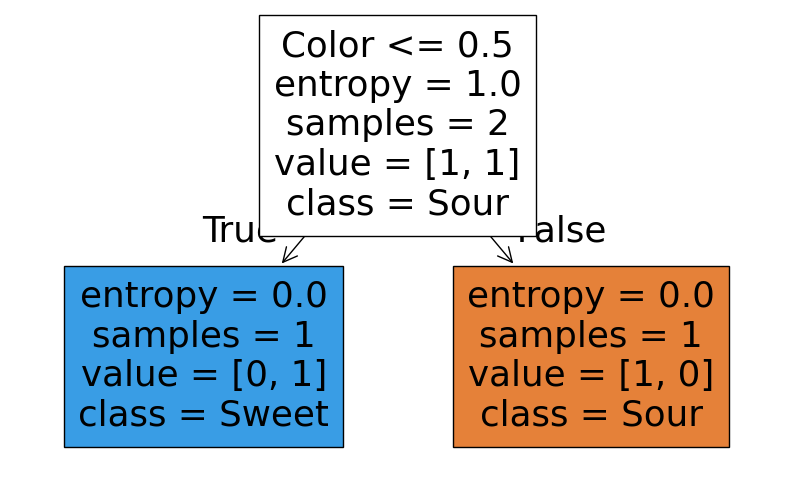

In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create the Fruits Details Dataset (Table 4.6)
data = {
    'Fruit': ['Apple', 'Banana', 'Orange', 'Strawberry'],
    'Color': ['Red', 'Yellow', 'Orange', 'Red'],
    'Size': ['Large', 'Medium', 'Small', 'Small'],
    'Sweetness': ['Sweet', 'Sweet', 'Sour', 'Sweet']
}

df = pd.DataFrame(data)

#Tạo một hàm để tính entropy
def calculate_entropy(column):
    value_counts = column.value_counts(normalize = True)
    entropy = -sum(value_counts * np.log2(value_counts + 1e-9))
    return entropy 
# Tính entropy cho từng thuộc tính
for col in df.columns[1:]:# Bỏ qua cột 'Fruit' vì nó là nhãn
    entropy = calculate_entropy(df[col])
    print(f'Entropy of {col}: {entropy:.4f}')

#tạo một hàm để tính information gain 
def information_gain(df , split_attribute, target_attribute):
    total_entropy = calculate_entropy(df[target_attribute])
    # Tính entropy sau khi chia theo thuộc tính split_attribute
    value_counts = df[split_attribute].value_counts(normalize = True)
    weighted_entropy = 0 
    for value , weight in value_counts.items():
        subset = df[df[split_attribute] ==value ]
        subset_entropy = calculate_entropy(subset[target_attribute])
        weighted_entropy += weight * subset_entropy
    info_gain = total_entropy - weighted_entropy
    return info_gain

#tính information gain cho từng thuộc tính
target_attribute = 'Fruit'
for col in df.columns[1:]:
    info_gain = information_gain(df, col , target_attribute)
    print(f'Information Gain of {col}: {info_gain:.4f}')

#ứng dụng thuật toán id3 để phân loại trái cây
# Chuyển đổi các thuộc tính phân loại thành số
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns: 
    df[col] = le.fit_transform(df[col])

X = df[['Color']]
y = df['Fruit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

DecisionTree = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
#Tạo một mô hình tree và xây dựng cái tree branch dùng thuộc tính tốt nhất 
DecisionTree.fit(X_train, y_train)
y_pred = DecisionTree.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Build and displace a decision tree
from sklearn import tree
plt.figure(figsize=(10,6))
tree.plot_tree(DecisionTree, feature_names = ['Color'], class_names = le.classes_, filled = True)
# Show the plot
plt.show()



R^2 Score for Gradient Boosting Regressor: -0.1410
Mean Squared Error for Gradient Boosting Regressor: 92424335.5093


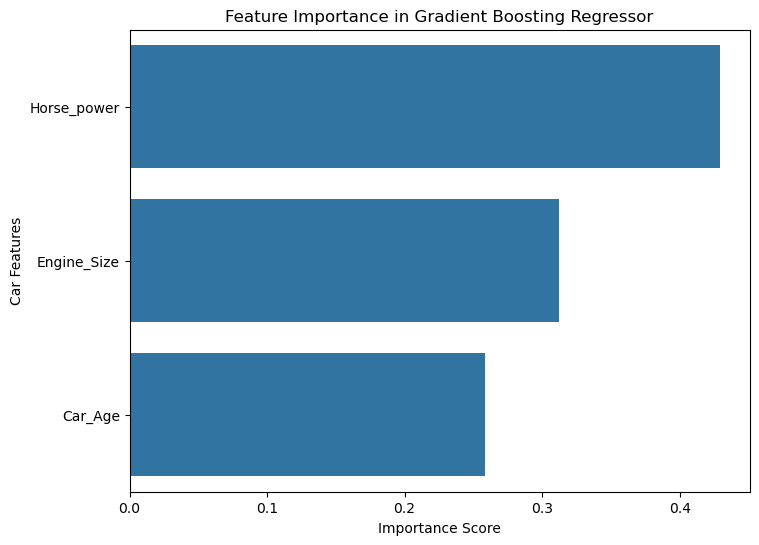

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score , mean_squared_error

car_data = {
    'Horse_power': [120, 140, 135, 110, 200],
    'Engine_Size': [2.0, 2.5, 3.0, 3.5, 4.0],
    'Car_Age': [2, 3, 4, 1, 5],
    'Price($)': [22000, 30000, 13000, 32000, 12000]
}

car_df = pd.DataFrame(car_data)
y = car_df['Price($)']
X = car_df.drop('Price($)', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

GradientBoosting = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1 , max_depth = 3 , random_state = 42)
GradientBoosting.fit(X_train , y_train)
y_gradient_pred = GradientBoosting.predict(X_test)


r2 = r2_score(y_test, y_gradient_pred)
print(f'R^2 Score for Gradient Boosting Regressor: {r2:.4f}')
mse = mean_squared_error(y_test, y_gradient_pred)
print(f'Mean Squared Error for Gradient Boosting Regressor: {mse:.4f}')


feature_importances = GradientBoosting.feature_importances_
features = X.columns 
plt.figure(figsize=(8,6))
sns.barplot(x = feature_importances , y = features)
plt.title('Feature Importance in Gradient Boosting Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Car Features')
plt.show()